# 5n-MRC Analysis

In [1]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [2]:
# paths to simulations
path1 = "/data/geissler/simulations/rec_lig/5n-mrc/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/rec_lig/5n-mrc/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/rec_lig/5n-mrc/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/rec_lig/5n-mrc/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/rec_lig/5n-mrc/combined/stats/"  # path to save results

## RMSD Calcium and Ligand to pocket

### Cal to pocket

RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.

In [24]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, 15003)
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, 15003)

In [25]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [26]:
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

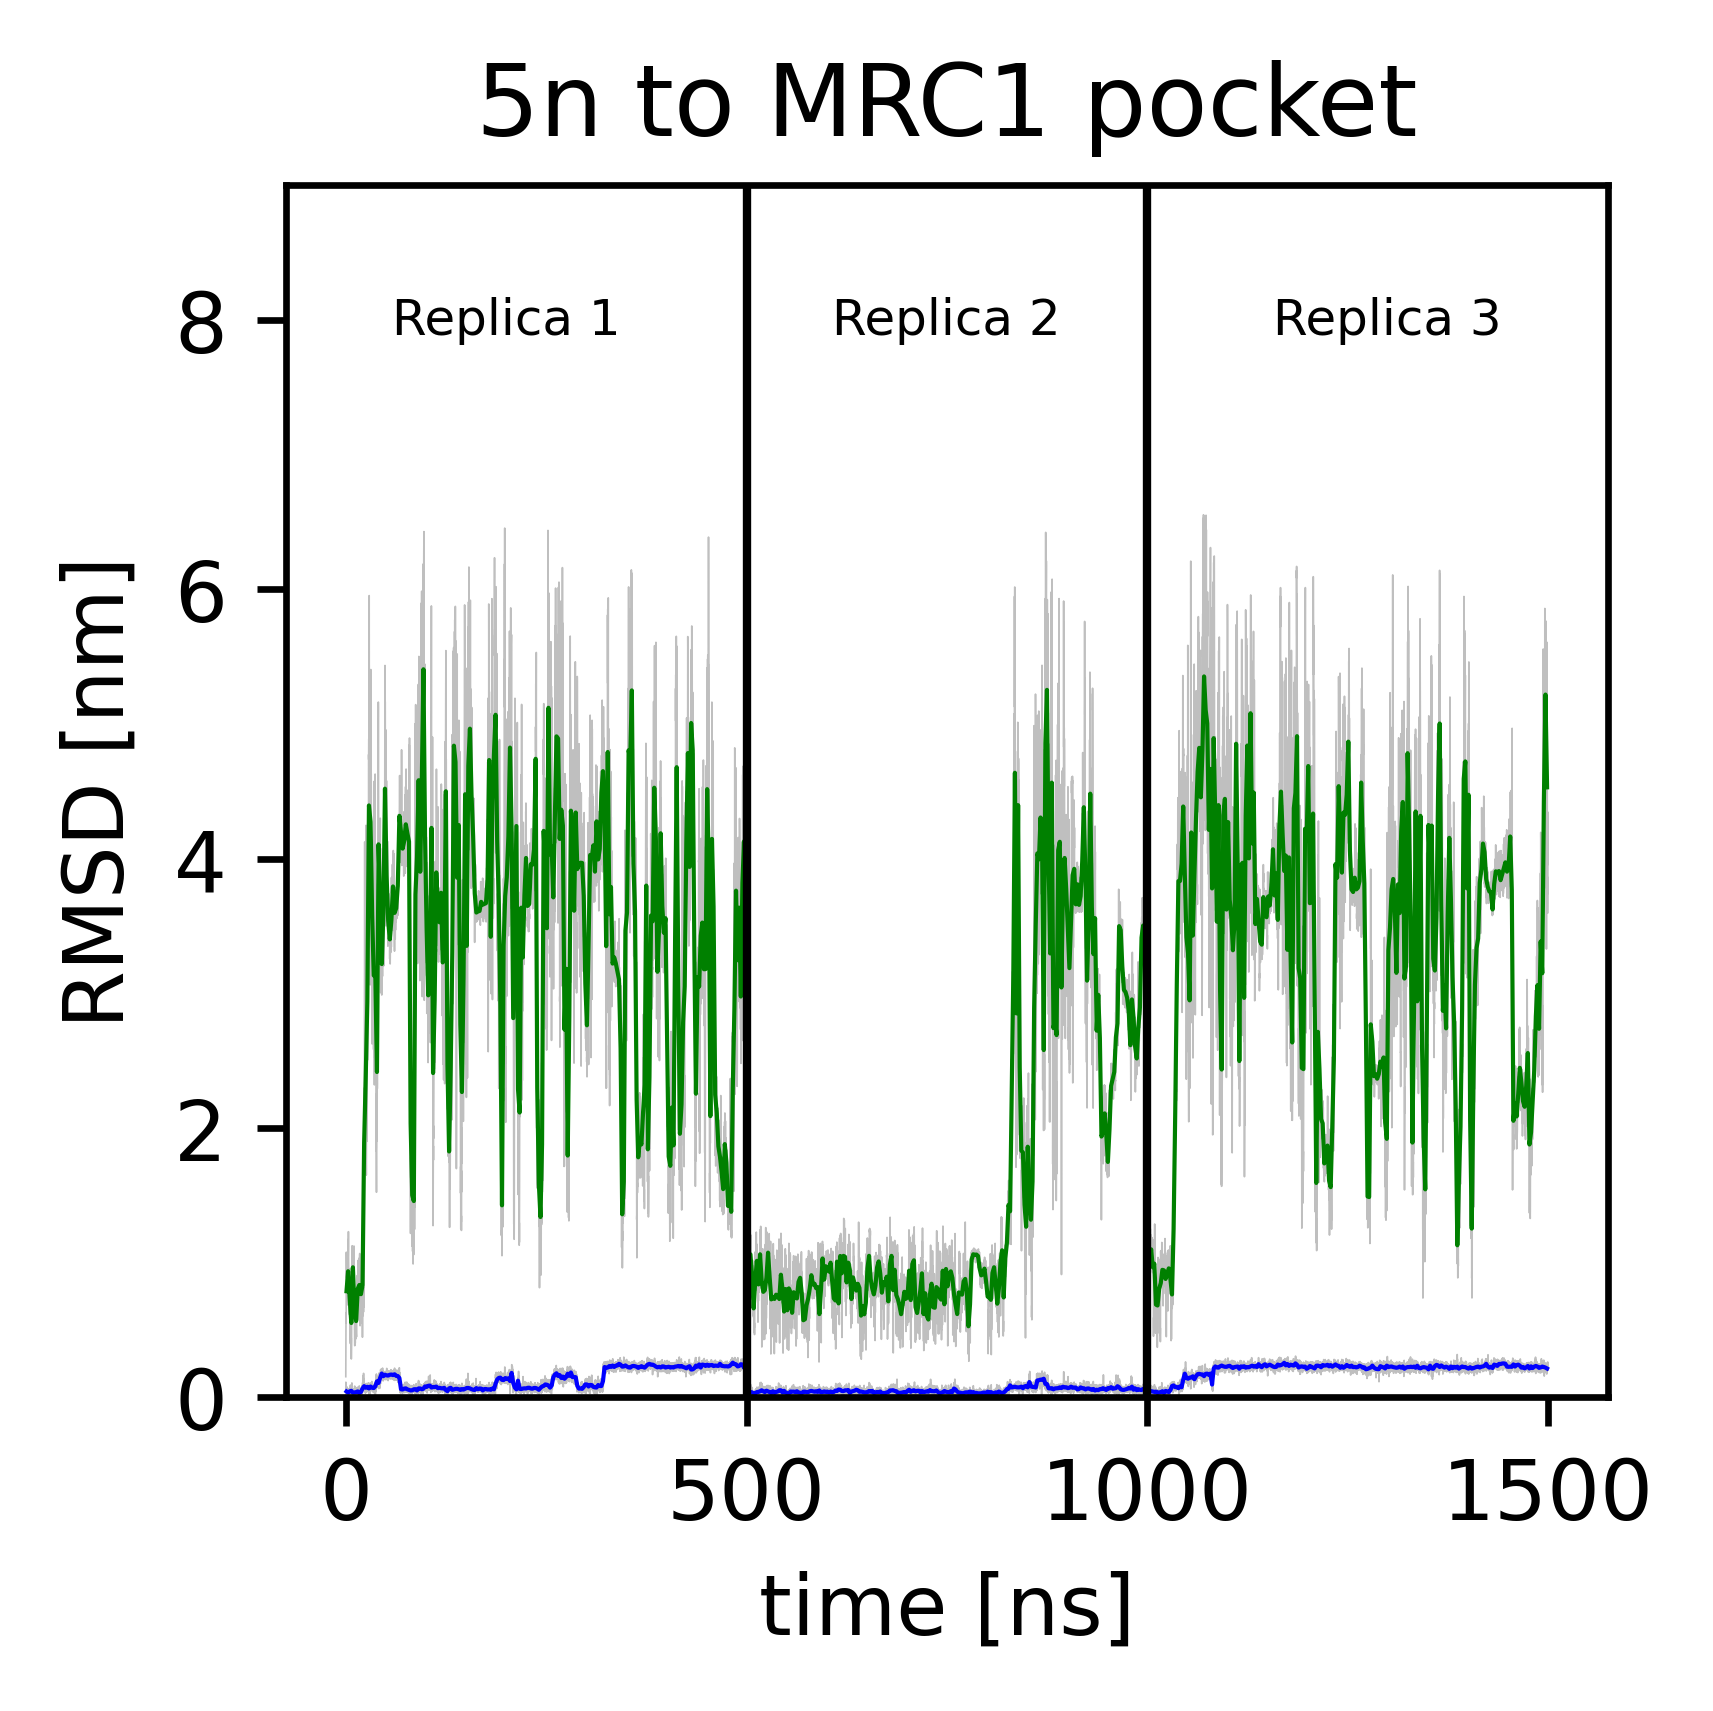

In [28]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('5n to MRC1 pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
plt.savefig("/data/geissler/analysis/RMSD/cal_lig/5n-mrc.png")

## different binding states

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu725, HO3 being close to Glu733, HO6 being far away from Glu737 and HO2 being far away from Glu725
- "state A" is defined by HO2 being close to Glu725, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu733
- "state B" is defined by HO2 being close to Glu733, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu725
- "state C" is defined by HO6 being close to Glu737, HO3 being close to Glu733 and HO2 being far from Glu725 

In [4]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [5]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 737
man = traj.select_atoms('resname LIG and name HO6')
prot = traj.select_atoms('protein and resid 737 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [6]:
# distance 2: HO2 to Glutamic Acid 725
man = traj.select_atoms('resname LIG and name HO2')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [7]:
# distance 3: HO3 to Glutamic Acid 733
man = traj.select_atoms('resname LIG and name HO3')
prot = traj.select_atoms('protein and resid 733 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [8]:
# distance 4: HO4 to Glutamic Acid 725 
man = traj.select_atoms('resname LIG and name HO4')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [9]:
# distance 5: HO2 to Glutamic Acid 733
man = traj.select_atoms('resname LIG and name HO2')  
prot = traj.select_atoms('protein and resid 733 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [10]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save('distances_flat.npy', distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [11]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

3241


In [12]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

1


In [13]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

387


In [14]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

0


In [15]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

134

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
I will make trajectories between 100 and 300 frames, to have better comparability.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 221 frames, 22 ns, 22100 ps
- 2rep bound: 3231 frames, 323 ns, 323100 ps
- 3rep bound: 311 frames, 31 ns, 31100 ps

  3763 frames in total -> 376300 ps

### crystal state

In [16]:
ps = 100
crystal_ps= [x*ps for x in crystal] 
print(*crystal_ps[:300])

0 100 200 300 400 500 600 700 800 900 1000 1100 1200 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 2500 2600 2700 2800 2900 3000 3100 3400 3500 3600 3700 3900 4000 4100 4200 4300 4400 4500 4600 4700 4800 4900 5000 5100 5200 5300 5400 5500 5600 5800 5900 6000 6100 6200 6400 6500 6600 6700 6800 6900 7000 7200 7300 7400 7500 7600 7700 7800 7900 8000 8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 9100 9200 9300 9400 9500 9600 9700 9800 9900 10000 10100 10200 10300 10400 10500 10600 10700 10800 10900 11100 11200 11300 11400 11500 11600 11700 11800 11900 12000 12100 12200 12300 12400 12500 12600 12700 12800 12900 13000 13100 13200 13300 13400 13500 13600 13700 13800 13900 14000 14100 14200 14300 14400 14500 14600 14700 14800 14900 15000 15100 15200 15300 15400 15500 15600 15700 15800 15900 16000 16100 16200 16300 16400 16600 16700 16900 17000 17100 17200 17300 17400 17500 17600 17700 17800 17900 18000 18100 18200 18300 18400 18500 18600 18700 18800 18900 19000 19100 19200 19

In [20]:
print('frames in 2rep:')
for i in crystal_ps[:600]:
    if i > 22100 and i <= (22100+323100):
        print(i-22100)

frames in 2rep:
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1600
1700
1800
1900
2000
2100
2200
2400
2500
2600
3400
3500
3600
3700
3800
3900
4100
4300
4400
4700
4900
5000
5200
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16900
18200
18400
19000
19100
19200
19300
19400
19500
19600
19700
19900
20000
20200
20300
20400
20500
20600
20800
20900
21000
21100
21200
21400
21600
21900
22000
22100
22200
22300
22400
22500


In [19]:
print('frames in 3rep:')
for i in crystal_ps[:1000]:
    if i > (22100+323100):
        print(i-(22100+323100))

frames in 3rep:


### state A has less than 100 frames

### state B

In [21]:
ps = 100
stateB_ps= [x*ps for x in stateB] 
print(*stateB_ps[:300])

5700 6300 7100 11000 19300 22200 23600 24400 24800 25200 25300 25400 26100 26300 26600 26700 26900 27200 27400 37200 38700 38800 38900 39100 39200 39300 39400 39500 39600 39700 39800 39900 40000 40100 40200 40400 40600 40700 40800 40900 41000 41900 42200 42800 43400 43600 43800 43900 47300 47400 47500 47800 64200 65900 66000 66100 66300 67900 68000 68100 68200 68600 68800 68900 74100 75800 76300 76400 76500 76700 78000 85600 98900 104000 104900 105300 106600 107500 108400 109000 113000 118100 119300 128200 128300 130400 133200 133400 133500 133600 133700 133800 133900 134000 134200 134800 135900 136000 136200 136300 136400 136500 138000 138100 138300 138500 138600 139100 140900 141600 143500 144100 144400 144500 144600 144900 146700 146900 149500 149700 153900 154800 160500 160600 161300 161900 162000 162700 163100 163200 163300 163400 163500 163800 163900 164000 164300 164400 164500 164600 164700 165000 175200 175800 176000 176100 176200 176300 176400 181000 182300 184300 196800 19690

In [22]:
print('frames in 1rep:')
for i in stateB_ps[:300]:
    if i <= 22100:
        print(i)

frames in 1rep:
5700
6300
7100
11000
19300


In [23]:
print('frames in 2rep:')
for i in stateB_ps[:500]:
    if i > 22100 and i <= (22100+323100):
        print(i-22100)

frames in 2rep:
100
1500
2300
2700
3100
3200
3300
4000
4200
4500
4600
4800
5100
5300
15100
16600
16700
16800
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18300
18500
18600
18700
18800
18900
19800
20100
20700
21300
21500
21700
21800
25200
25300
25400
25700
42100
43800
43900
44000
44200
45800
45900
46000
46100
46500
46700
46800
52000
53700
54200
54300
54400
54600
55900
63500
76800
81900
82800
83200
84500
85400
86300
86900
90900
96000
97200
106100
106200
108300
111100
111300
111400
111500
111600
111700
111800
111900
112100
112700
113800
113900
114100
114200
114300
114400
115900
116000
116200
116400
116500
117000
118800
119500
121400
122000
122300
122400
122500
122800
124600
124800
127400
127600
131800
132700
138400
138500
139200
139800
139900
140600
141000
141100
141200
141300
141400
141700
141800
141900
142200
142300
142400
142500
142600
142900
153100
153700
153900
154000
154100
154200
154300
158900
160200
162200
174700
174800
174900
175000
175100
175200
175300

In [20]:
print('frames in 3rep:')
for i in stateB_ps[:500]:
    if i > (139100+500100):
        print(i-(139100+500100))

frames in 3rep:
1000
4700
5800
6400
8200
8400
8700
9000
9100
9200
9600
10200
10600
10800
11000
11300
11400
12600
15600
15700
16600
18900
21200
22600
22700
22800
22900
29300
29400
29700
30100
32800
32900
33300
33500
33600
33800
33900
34000
34100
34200
34300
34500
34600
34700
34800
36000
39400
43200
48000
48300
48600
49000
51500
51600
51700
54500
56900
57600
57900
58000
58200
58500
58600
58700
58900
59100
59300
59800
59900
60000
60100
60400
60600
60700
60800
61000
61100
61400
61500
61600
61900
62000
62200
62400
75000
75100
77100
77300
77400
77700
78000
86200
87000
87100
87200
87300
87400
87800
88400
88500
88700
94100
101800
102900
103400
106700
106800
106900
113400
115100
116800
117800
118800
119700
120100
120200
120300
120400
120500
120600
120800
120900
131800
132600
135300
138300
138400
138500
138600
138800
138900
139000
139100
139200
139300
139400
139500
139600
139700
139800
139900
140000
140100
140200
140300
140400
140500
140600
140700
140800
140900
141000
141100
141200
141300
141400

### state C has less than 100 frames